# Ostoskärrydatan tutkimus (03) - Data Pipeline & Konversio-analyysi

## 1. Ympäristön ja Asetusten Alustus

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
from matplotlib.colors import LogNorm
import ipywidgets as widgets
from ipywidgets import interact

warnings.filterwarnings('ignore')

# Asetetaan visuaalinen tyyli
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Tarkistetaan ja luodaan datakansiot
raw_data_path = Path('data/raw')
processed_data_path = Path('data/processed')
processed_data_path.mkdir(parents=True, exist_ok=True)

print(f"Raw data path: {raw_data_path}")
print(f"Processed data path: {processed_data_path}")
print(f"\nRaakatiedostot: {[f.name for f in raw_data_path.glob('*.csv')] if raw_data_path.exists() else 'Kansiota ei löydy'}")

Raw data path: data/raw
Processed data path: data/processed

Raakatiedostot: ['node_53936.csv', 'node_53795.csv', 'node_53000.csv', 'node_51968.csv', 'node_51992.csv', 'node_53924.csv', 'node_64458.csv', 'node_51866.csv', 'node_54016.csv', 'node_52535.csv', 'node_52008.csv', 'node_51751.csv', 'node_42787.csv', 'node_53888.csv', 'node_53130.csv', 'node_45300.csv', 'node_51719.csv', 'node_51976.csv', 'node_53027.csv', 'node_3240.csv', 'node_52003.csv', 'node_51850.csv', 'node_52023.csv', 'node_53768.csv', 'node_51889.csv', 'node_3224.csv', 'node_51720.csv', 'node_3200.csv', 'node_51735.csv', 'node_52099.csv', 'node_53011.csv']


## 2. Datan lataus

In [19]:
# Ladataan raakadata CSV-tiedostoista (esimerkkidata logiikan rakentamiseen)
raw_file = 'data/raw/node_3224.csv'  # Voit muuttaa tätä halutessasi

try:
    df = pd.read_csv(raw_file)
    print(f"✓ Data ladattu onnistuneesti: {raw_file}")
    print(f"\n📊 Datan koko: {df.shape[0]:,} riviä, {df.shape[1]} saraketta")
    print(f"\n📋 Sarakkeet: {list(df.columns)}")
except FileNotFoundError:
    print(f"✗ Virhe: Tiedostoa {raw_file} ei löydy.")
    print("Varmista, että data on ladattu data/raw/ -kansioon.")

✓ Data ladattu onnistuneesti: data/raw/node_3224.csv

📊 Datan koko: 6,136,400 riviä, 6 saraketta

📋 Sarakkeet: ['node_id', 'timestamp', 'x', 'y', 'z', 'q']


## 3. Siivousasetukset ja Tuotantotason ETL-Funktiot

In [20]:
# Tuotantotason datan siivous -asetukset
CLEANING_CONFIG = {
    'Q_THRESHOLD': 0.0,                  # Q-arvojen minimitaso
    'SHOP_HOURS': {
        'mon-sat': (8, 21),              # Ma-Su: 08:00-21:00
        'sunday': (10, 20)               # Su: 10:00-20:00
    },
    'PROBLEMATIC_COORDS': [
        {'x': 100, 'y': 2500, 'radius': 400}, # Latauspiste 1 (Turvaportit)
        {'x': 900, 'y': 3600, 'radius': 600}  # Latauspiste 2 (Liukuportaat)
    ],
    
    # ALUE-MÄÄRITYKSET (Geofencing)
    'CHECKOUT_ZONE': {
        'x_min': 0, 'x_max': 700,        # Kassa-alue ja poistumistie
        'y_min': 0, 'y_max': 5220
    },
    'REQUIRE_START_ZONE': True,          # Vaaditaan, että reissu alkaa sisäänkäynniltä
    'START_ZONE': {
        'x_min': 0, 'x_max': 1200,       # Sisäänkäynnin sallittu aloitusalue (Säädä tarvittaessa)
        'y_min': 0, 'y_max': 5220
    },
    
    # LIIKETOIMINTALOGIIKKA JA SESSIOIDEN ÄLYKÄS PILKKOMINEN
    'SESSION_GAP_THRESHOLD': 900,        # Signaalikatkos (s), jonka jälkeen sessio katkaistaan (15 min)
    'REQUIRE_CHECKOUT': True,           
    
    # UUSI: PAIKALLAANOLO-LEIKKURI (Karsii hylätyt kärryt, mutta säilyttää alun)
    'SESSION_LOGIC': {
        'STATIONARY_RADIUS_CM': 500,     # Säde (cm) = 5 metriä
        'STATIONARY_TIMEOUT_SEC': 1200   # Aika (s) = 20 minuuttia paikoillaan, ja sessio poikki
    },
    
    # JITTER- JA HAAMUSUODATTIMET (Fysiologiset rajat)
    'MAX_JUMP_SPEED': 3.0,               # Max sallittu hyppy kahden pisteen välillä (m/s)
    'MAX_AVG_SPEED': 1.5,                # Max sallittu koko reissun keskinopeus (m/s)
    'MIN_AVG_SPEED': 0.08,               # Pienin sallittu keskinopeus. Karsii hylätyt kärryt.
    'MIN_SPATIAL_SPREAD': 15.0,          # Reitin on levittäydyttävä vähintään 15m säteelle (karsii "paikallaan hyppivät")
    'MIN_SESSION_POINTS': 30,            # Pienin sallittu datapisteiden määrä per reissu
    'MIN_SESSION_DIST': 30.0,            # Pienin kuljettu matka (metriä)
    'MAX_SESSION_DIST': 8000.0,          # Suurin sallittu matka (8 km)
    'MIN_SESSION_TIME': 180,             # Pienin sallittu kesto (3 minuuttia)
    'MAX_SESSION_TIME': 14400,           # Suurin sallittu kesto (4 tuntia)
    
    # YMPÄRISTÖN PARAMETRIT
    'START_COORDINATES': (0, 0),
    'MAX_X': 10406,                      # Kaupan maksimileveys (1 yksikkö = 1 cm)
    'MAX_Y': 5220,                       # Kaupan maksimikorkeus
    'FLIP_Y': True,                      # Käännetäänkö Y-akseli pohjapiirroksen mukaiseksi?
    'TIMEZONE': 'Europe/Helsinki',
    'FILTER_SHOP_HOURS': True,
    'FILTER_CHECKOUT': True              # Piilotetaanko kassa-alue kuvaajien siistimiseksi?
}

print("⚙️ Siivouskonfiguraatio ladattu onnistuneesti.")
print(f"  - Sessiokatkaisu: > {CLEANING_CONFIG['SESSION_GAP_THRESHOLD']/60:.1f} min signaalikatkos = uusi asiakas")
print(f"  - Paikallaanolo-detector: > {CLEANING_CONFIG['SESSION_LOGIC']['STATIONARY_TIMEOUT_SEC']/60:.0f} min ilman > {CLEANING_CONFIG['SESSION_LOGIC']['STATIONARY_RADIUS_CM']/100:.0f}m liikettä")
print(f"  - Reissun matkarajat: {CLEANING_CONFIG['MIN_SESSION_DIST']} - {CLEANING_CONFIG['MAX_SESSION_DIST']} metriä")
print(f"  - Aikarajat: {CLEANING_CONFIG['MIN_SESSION_TIME']/60:.0f} - {CLEANING_CONFIG['MAX_SESSION_TIME']/60:.0f} minuuttia")
print(f"  - Spatial Spread (Jitter-suodatin): Reitin on levittäydyttävä > {CLEANING_CONFIG['MIN_SPATIAL_SPREAD']} m alueelle")

⚙️ Siivouskonfiguraatio ladattu onnistuneesti.
  - Sessiokatkaisu: > 15.0 min signaalikatkos = uusi asiakas
  - Paikallaanolo-detector: > 20 min ilman > 5m liikettä
  - Reissun matkarajat: 30.0 - 8000.0 metriä
  - Aikarajat: 3 - 240 minuuttia
  - Spatial Spread (Jitter-suodatin): Reitin on levittäydyttävä > 15.0 m alueelle


In [21]:
def clean_data(df, config):
    df_clean = df.copy()
    stats = {'original_rows': len(df_clean)}
    
    critical_columns = ['node_id', 'timestamp', 'x', 'y', 'z']
    df_clean = df_clean.dropna(subset=[c for c in critical_columns if c in df_clean.columns])
    df_clean = df_clean.drop_duplicates(subset=['node_id', 'timestamp'])
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], utc=True).dt.tz_convert(config['TIMEZONE'])
    
    before = len(df_clean)
    invalid_coords = df_clean[
        (df_clean['x'] < 0) | (df_clean['x'] > config['MAX_X']) |
        (df_clean['y'] < 0) | (df_clean['y'] > config['MAX_Y'])
    ].index
    df_clean = df_clean.drop(invalid_coords)
    stats['removed_invalid_coords'] = before - len(df_clean)

    if config.get('FLIP_Y', False):
        df_clean['y'] = config['MAX_Y'] - df_clean['y']

    before = len(df_clean)
    mask = pd.Series(False, index=df_clean.index)
    for area in config['PROBLEMATIC_COORDS']:
        area_y = config['MAX_Y'] - area['y'] if config.get('FLIP_Y', False) else area['y']
        in_x = (df_clean['x'] >= area['x'] - area['radius']) & (df_clean['x'] <= area['x'] + area['radius'])
        in_y = (df_clean['y'] >= area_y - area['radius']) & (df_clean['y'] <= area_y + area['radius'])
        mask = mask | (in_x & in_y)
    df_clean = df_clean[~mask]
    stats['removed_problematic_coords'] = before - len(df_clean)

    before = len(df_clean)
    start_rows = df_clean[
        (df_clean['x'] == config['START_COORDINATES'][0]) & 
        (df_clean['y'] == config['START_COORDINATES'][1])
    ].index
    df_clean = df_clean.drop(start_rows)
    stats['removed_start_coords'] = before - len(df_clean)

    if 'q' in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean[df_clean['q'] >= config['Q_THRESHOLD']]
        stats['removed_q_negative'] = before - len(df_clean)
    
    if config['FILTER_SHOP_HOURS']:
        before = len(df_clean)
        df_clean['hour'] = df_clean['timestamp'].dt.hour
        df_clean['weekday'] = df_clean['timestamp'].dt.day_name()
        is_weekday = df_clean['weekday'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
        is_sunday = df_clean['weekday'] == 'Sunday'
        valid_weekday_hours = (df_clean['hour'] >= config['SHOP_HOURS']['mon-sat'][0]) & (df_clean['hour'] < config['SHOP_HOURS']['mon-sat'][1])
        valid_sunday_hours = (df_clean['hour'] >= config['SHOP_HOURS']['sunday'][0]) & (df_clean['hour'] < config['SHOP_HOURS']['sunday'][1])
        df_clean = df_clean[(is_weekday & valid_weekday_hours) | (is_sunday & valid_sunday_hours)]
        stats['removed_shop_hours'] = before - len(df_clean)

    if df_clean.empty:
        stats['final_rows'] = 0
        return df_clean, stats

    # SESSIOIDEN MÄÄRITYS
    df_clean = df_clean.sort_values(['node_id', 'timestamp']).reset_index(drop=True)
    cz = config['CHECKOUT_ZONE']
    in_checkout = (df_clean['x'] >= cz['x_min']) & (df_clean['x'] <= cz['x_max']) & \
                  (df_clean['y'] >= cz['y_min']) & (df_clean['y'] <= cz['y_max'])
    
    node_changed = df_clean['node_id'] != df_clean['node_id'].shift(1)
    time_diff_sec = df_clean['timestamp'].diff().dt.total_seconds().fillna(0)
    time_diff_sec = np.where(node_changed, 0.0, time_diff_sec)
    
    left_checkout = (~in_checkout) & (in_checkout.shift(1).fillna(False)) & (~node_changed)
    time_gap = time_diff_sec > config['SESSION_GAP_THRESHOLD']
    
    is_new_session = node_changed | time_gap | left_checkout
    df_clean['session_id'] = is_new_session.cumsum()
    df_clean['full_session_id'] = df_clean['node_id'].astype(str) + "_" + df_clean['session_id'].astype(str)

    # NOPEUS/JUMP-FILTTERI
    session_changed = df_clean['full_session_id'] != df_clean['full_session_id'].shift(1)
    df_clean['dt'] = np.where(session_changed, 0.0, df_clean['timestamp'].diff().dt.total_seconds().fillna(0))
    df_clean['dx'] = np.where(session_changed, 0.0, df_clean['x'].diff().fillna(0))
    df_clean['dy'] = np.where(session_changed, 0.0, df_clean['y'].diff().fillna(0))
    df_clean['dist_m'] = np.sqrt(df_clean['dx']**2 + df_clean['dy']**2) * 0.01
    df_clean['speed_mps'] = np.where(df_clean['dt'] > 0, df_clean['dist_m'] / df_clean['dt'], 0.0)

    before_jumps = len(df_clean)
    bad_jumps_mask = df_clean['speed_mps'] > config['MAX_JUMP_SPEED']
    df_clean = df_clean[~bad_jumps_mask].copy()
    
    if df_clean.empty: return df_clean, stats

    # UUDELLEENLASKENTA
    df_clean = df_clean.sort_values(['full_session_id', 'timestamp']).reset_index(drop=True)

    # =========================================================================
    # PAIKALLAANOLO-LEIKKURI
    # =========================================================================
    sl = config['SESSION_LOGIC']
    radius_sq = sl['STATIONARY_RADIUS_CM']**2 
    timeout_sec = sl['STATIONARY_TIMEOUT_SEC']
    
    indices_to_drop = []
    active_cuts = 0
    
    for sess_id, sess_data in df_clean.groupby('full_session_id'):
        x = sess_data['x'].values
        y = sess_data['y'].values
        
        timestamps = (sess_data['timestamp'] - sess_data['timestamp'].iloc[0]).dt.total_seconds().values
        idx = sess_data.index.values
        
        n = len(x)
        if n < 2: continue
            
        left = 0
        cut_session = False
        
        for right in range(n):
            while timestamps[right] - timestamps[left] >= timeout_sec:
                x_window = x[left:right+1]
                y_window = y[left:right+1]
                
                # Etsitään massakeskipiste
                med_x = np.median(x_window)
                med_y = np.median(y_window)
                
                # Ovatko 80% pisteistä säteen sisällä keskipisteestä?
                dist_sq = (x_window - med_x)**2 + (y_window - med_y)**2
                fraction_inside = np.mean(dist_sq <= radius_sq)
                
                if fraction_inside >= 0.80:
                    indices_to_drop.extend(idx[left+1:])
                    active_cuts += 1
                    cut_session = True
                    break
                else:
                    left += 1
            if cut_session: break
                
    before_len = len(df_clean)
    if indices_to_drop:
        df_clean = df_clean.drop(indices_to_drop)
        print(f"🗑️  Paikallaanolo-leikkuri heräsi: katkoi {active_cuts} reissua keskeltä kauppaa.")
        
    stats['removed_by_timeout'] = before_len - len(df_clean)

    # Uudelleenlasketaan etäisyydet leikkuun jälkeen
    df_clean = df_clean.sort_values(['full_session_id', 'timestamp']).reset_index(drop=True)
    session_changed = df_clean['full_session_id'] != df_clean['full_session_id'].shift(1)
    df_clean['dt'] = np.where(session_changed, 0.0, df_clean['timestamp'].diff().dt.total_seconds().fillna(0))
    df_clean['dx'] = np.where(session_changed, 0.0, df_clean['x'].diff().fillna(0))
    df_clean['dy'] = np.where(session_changed, 0.0, df_clean['y'].diff().fillna(0))
    df_clean['dist_m'] = np.sqrt(df_clean['dx']**2 + df_clean['dy']**2) * 0.01

    # =========================================================================
    # ALOITUS- JA LOPPUVALIDOINNIT
    # =========================================================================
    if config.get('REQUIRE_START_ZONE', True):
        sz = config['START_ZONE']
        first_points = df_clean.groupby('full_session_id').first()
        valid_starts = first_points[
            (first_points['x'] >= sz['x_min']) & (first_points['x'] <= sz['x_max']) &
            (first_points['y'] >= sz['y_min']) & (first_points['y'] <= sz['y_max'])
        ].index
        before_len = len(df_clean)
        df_clean = df_clean[df_clean['full_session_id'].isin(valid_starts)].copy()

    # KASSAVELVOITE TUHOAA LEIKATUT MATKAT
    if config.get('REQUIRE_CHECKOUT', True):
        last_points = df_clean.groupby('full_session_id').tail(5)
        in_checkout_tail = last_points[
            (last_points['x'] >= cz['x_min']) & (last_points['x'] <= cz['x_max']) &
            (last_points['y'] >= cz['y_min']) & (last_points['y'] <= cz['y_max'])
        ]
        
        valid_ends = in_checkout_tail['full_session_id'].unique()
        before_len = len(df_clean)
        df_clean = df_clean[df_clean['full_session_id'].isin(valid_ends)].copy()
        stats['removed_no_checkout'] = before_len - len(df_clean)
        print(f"🗑️  Poistettu {stats['removed_no_checkout']:,} riviä (Reissu ei päättynyt kassoille).")

    # PIILOTA KASSAT
    if config.get('FILTER_CHECKOUT', True):
        in_checkout = (df_clean['x'] >= cz['x_min']) & (df_clean['x'] <= cz['x_max']) & \
                      (df_clean['y'] >= cz['y_min']) & (df_clean['y'] <= cz['y_max'])
        df_clean = df_clean[~in_checkout].copy()

    # LOPULLISET FYSIOLOGISET RAJAT
    session_stats = df_clean.groupby('full_session_id').agg(
        start_time=('timestamp', 'min'), end_time=('timestamp', 'max'), total_dist=('dist_m', 'sum'), point_count=('x', 'count'),
        min_x=('x', 'min'), max_x=('x', 'max'), min_y=('y', 'min'), max_y=('y', 'max')
    )
    
    session_stats['total_time'] = (session_stats['end_time'] - session_stats['start_time']).dt.total_seconds()
    session_stats['avg_speed'] = np.where(session_stats['total_time'] > 0, session_stats['total_dist'] / session_stats['total_time'], 0.0)
    session_stats['spatial_spread_m'] = np.sqrt((session_stats['max_x'] - session_stats['min_x'])**2 + (session_stats['max_y'] - session_stats['min_y'])**2) * 0.01
    
    bad_sessions = session_stats[
        (session_stats['avg_speed'] > config['MAX_AVG_SPEED']) | (session_stats['avg_speed'] < config['MIN_AVG_SPEED']) |
        (session_stats['spatial_spread_m'] < config['MIN_SPATIAL_SPREAD']) | (session_stats['point_count'] < config['MIN_SESSION_POINTS']) |
        (session_stats['total_dist'] < config['MIN_SESSION_DIST']) | (session_stats['total_dist'] > config['MAX_SESSION_DIST']) |
        (session_stats['total_time'] < config['MIN_SESSION_TIME']) | (session_stats['total_time'] > config['MAX_SESSION_TIME'])
    ].index
    
    df_clean = df_clean[~df_clean['full_session_id'].isin(bad_sessions)].copy()

    df_clean['speed_mps'] = np.where(df_clean['dt'] > 0, df_clean['dist_m'] / df_clean['dt'], 0.0)
    df_clean = df_clean.drop(columns=['dx', 'dy'])
    
    stats['final_rows'] = len(df_clean)
    return df_clean, stats

## 4. Tietovaraston Batch-prosessointi (Lataus ja Siivous)

In [22]:
raw_files = list(raw_data_path.glob('*.csv'))
all_dataframes = []
files_processed_count = 0

print("="*60)
print(" 🔄 DATAN BATCH-LATAUS JA KÄSITTELY ")
print("="*60)

for raw_file in raw_files:
    processed_file = processed_data_path / f"processed_{raw_file.name}"
    
    if processed_file.exists():
        print(f"✓ Ladataan valmiiksi prosessoitu: {processed_file.name}")
        df_proc = pd.read_csv(processed_file)
        df_proc['timestamp'] = pd.to_datetime(df_proc['timestamp'], utc=True).dt.tz_convert(CLEANING_CONFIG['TIMEZONE'])
        all_dataframes.append(df_proc)
    else:
        print(f"⚙️ Prosessoidaan uusi raakatiedosto: {raw_file.name}...")
        df_raw = pd.read_csv(raw_file)
        if len(df_raw) > 0:
            df_clean, stats = clean_data(df_raw, CLEANING_CONFIG)
            df_clean.to_csv(processed_file, index=False)
            all_dataframes.append(df_clean)
            files_processed_count += 1
        else:
            print(f"⚠️ Tiedosto {raw_file.name} oli tyhjä.")

if not all_dataframes:
    print("⚠️ Ei dataa saatavilla! Varmista että data/raw/ kansiossa on .csv tiedostoja.")
else:
    # Yhdistetään kaikkien kärryjen data yhdeksi isoksi analyysialustaksi
    df_cleaned = pd.concat(all_dataframes, ignore_index=True)
    
    # Varmistetaan ajan apusarakkeet analytiikkaa varten
    if 'year' not in df_cleaned.columns:
        df_cleaned['year'] = df_cleaned['timestamp'].dt.year
        df_cleaned['month'] = df_cleaned['timestamp'].dt.month
        df_cleaned['day'] = df_cleaned['timestamp'].dt.day
        df_cleaned['hour'] = df_cleaned['timestamp'].dt.hour
        df_cleaned['date'] = df_cleaned['timestamp'].dt.date
        df_cleaned['weekday'] = df_cleaned['timestamp'].dt.day_name()
    
    print(f"\n✅ Koko tietovarasto ladattu ja yhdistetty!")
    print(f"   - Prosessoitiin {files_processed_count} uutta tiedostoa.")
    print(f"   - Ladattiin {len(all_dataframes) - files_processed_count} valmista tiedostoa.")
    print(f"   - Analysoitavaa dataa yhteensä putsauksen jälkeen: {len(df_cleaned):,} datapistettä.")

 🔄 DATAN BATCH-LATAUS JA KÄSITTELY 
✓ Ladataan valmiiksi prosessoitu: processed_node_53936.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_53795.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_53000.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_51968.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_51992.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_53924.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_64458.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_51866.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_54016.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_52535.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_52008.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_51751.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_42787.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_53888.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_53130.csv
✓ Ladataan valmiiksi prosessoitu: processed_node_45300.csv
✓ Ladataan valmiiksi

## 📏 5. Kauppareissujen (Sessioiden) Tilastot ja Laadunvarmistus

In [23]:
print("="*60)
print(" 🛒 KOKONAISTILASTOT KAUPPAREISSUISTA ")
print("="*60)

unique_sessions = df_cleaned['full_session_id'].nunique()
print(f"\n👥 Asiakkaat ja Reissut:")
print(f"  - Kärryjä datasetissä (Nodeja): {df_cleaned['node_id'].nunique()}")
print(f"  - Hyväksyttyjä kauppareissuja (Sessioita): {unique_sessions:,}")
print(f"  - Keskimäärin mittauspisteitä per reissu: {len(df_cleaned) / unique_sessions:,.1f}")

print(f"\n📏 Kuljetut matkat (Sessioittain metreinä):")
session_distances = df_cleaned.groupby('full_session_id')['dist_m'].sum()
print(f"  - Keskiverto kauppareissun pituus: {session_distances.mean():.2f} metriä")
print(f"  - Lyhin mitattu reitti: {session_distances.min():.2f} metriä")
print(f"  - Pisin mitattu reitti: {session_distances.max():.2f} metriä")

# Kestot per sessio (Muutetaan tarkan maksimi- ja minimiajan mukaan)
session_durations = df_cleaned.groupby('full_session_id').apply(
    lambda x: (x['timestamp'].max() - x['timestamp'].min()).total_seconds() / 60.0
)

print(f"\n⏱️ Kauppareissujen kestot:")
print(f"  - Keskimääräinen aika kaupassa: {session_durations.mean():.1f} minuuttia")
print(f"  - Mediaaniaika kaupassa: {session_durations.median():.1f} minuuttia")
print(f"  - Lyhin yksittäinen vierailu: {session_durations.min():.1f} minuuttia")
print(f"  - Pisin yksittäinen vierailu: {session_durations.max():.1f} minuuttia")

 🛒 KOKONAISTILASTOT KAUPPAREISSUISTA 

👥 Asiakkaat ja Reissut:
  - Kärryjä datasetissä (Nodeja): 21
  - Hyväksyttyjä kauppareissuja (Sessioita): 8,505
  - Keskimäärin mittauspisteitä per reissu: 1,275.4

📏 Kuljetut matkat (Sessioittain metreinä):
  - Keskiverto kauppareissun pituus: 427.18 metriä
  - Lyhin mitattu reitti: 37.89 metriä
  - Pisin mitattu reitti: 1848.60 metriä

⏱️ Kauppareissujen kestot:
  - Keskimääräinen aika kaupassa: 20.8 minuuttia
  - Mediaaniaika kaupassa: 18.6 minuuttia
  - Lyhin yksittäinen vierailu: 3.0 minuuttia
  - Pisin yksittäinen vierailu: 124.2 minuuttia


## 🗺️ 6. Mittauspisteiden Lämpökartat (Koko Kauppa)


 🗺️ LÄMPÖKARTAT JA POHJAPIIRROS 
✓ Pohjapiirros ladattu: image/kauppa2.png


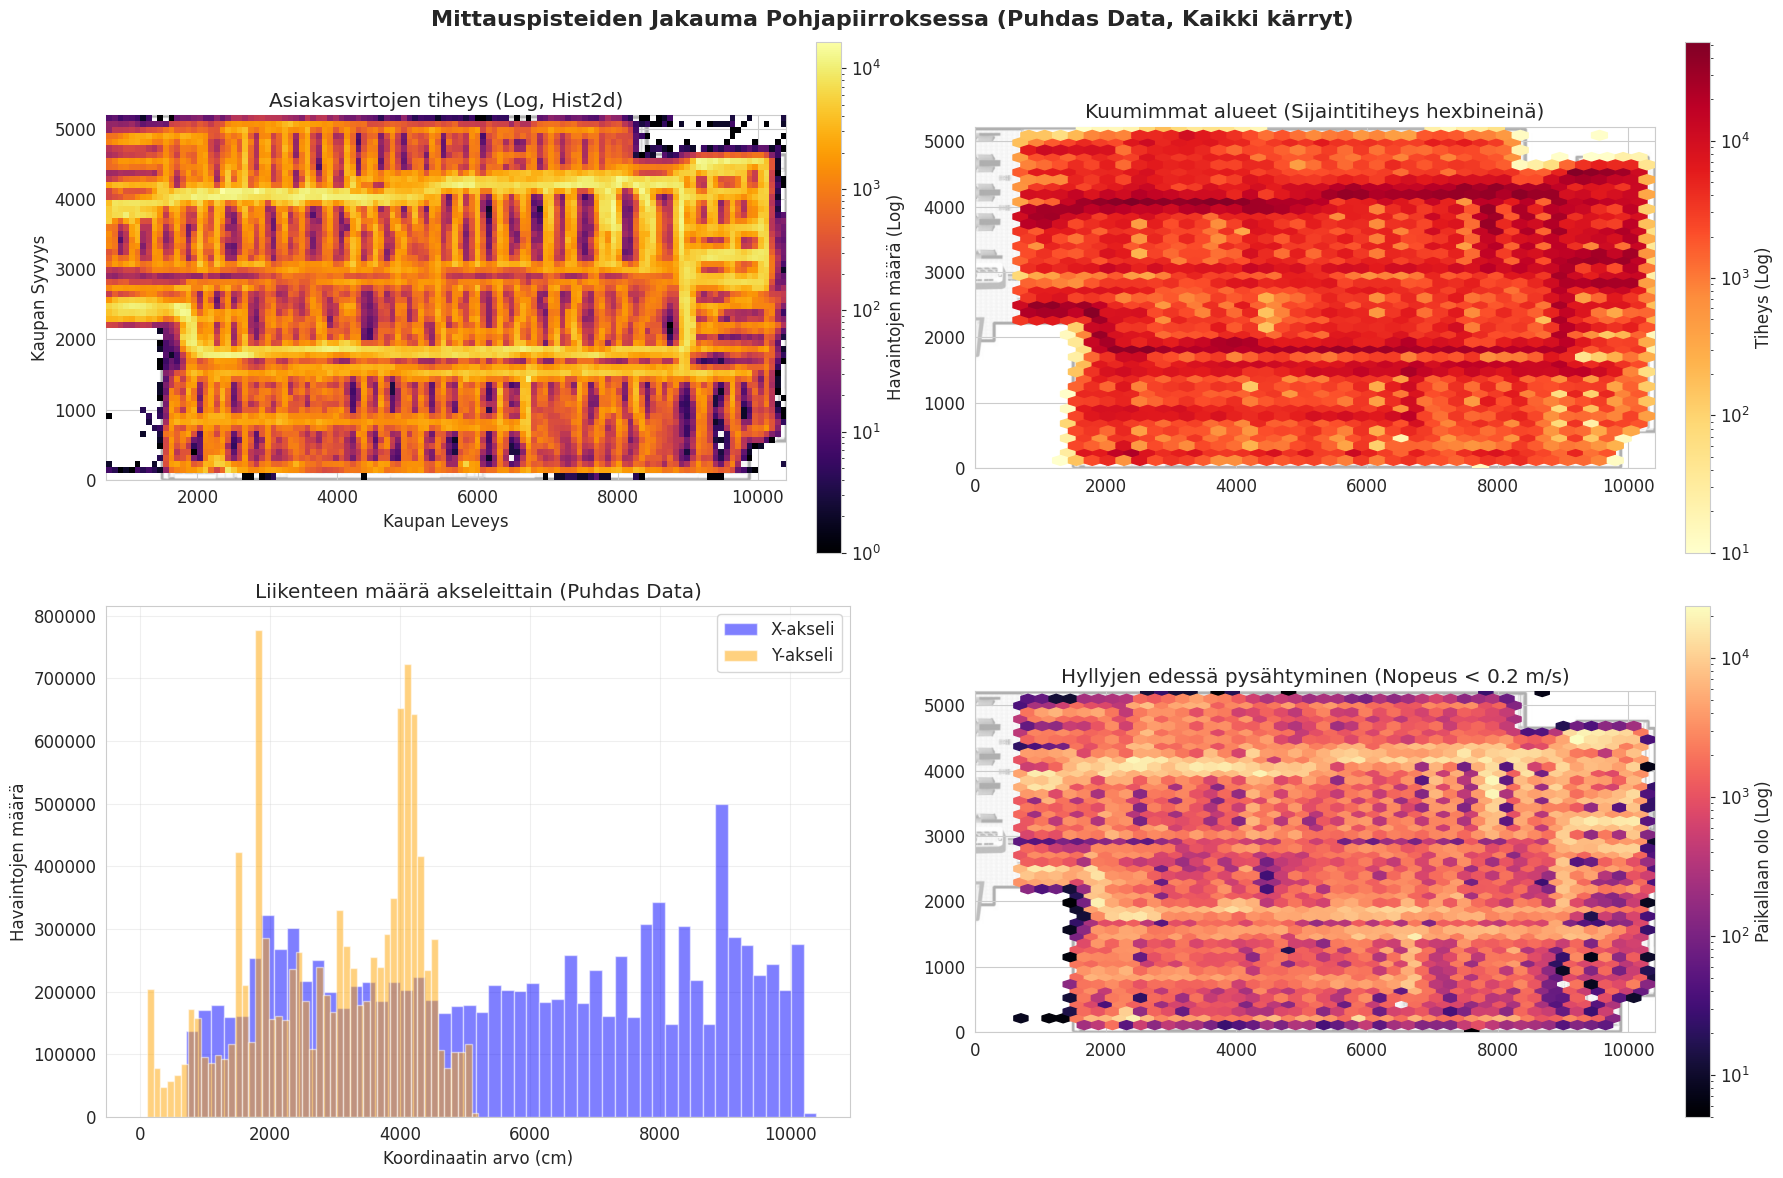

✅ Lämpökartat pohjapiirroksella luotu!


In [24]:
print("\n" + "="*60)
print(" 🗺️ LÄMPÖKARTAT JA POHJAPIIRROS ")
print("="*60)

# Lataa pohjapiirros
img_path = Path('image/kauppa2.png')
store_img = None
if img_path.exists():
    try:
        store_img = plt.imread(img_path)
        print(f"✓ Pohjapiirros ladattu: {img_path}")
    except Exception as e:
        print(f"✗ Virhe kuvan latauksessa: {e}. Piirretään ilman pohjapiirrosta.")
else:
    print(f"⚠️ Pohjapiirrosta ei löydy polusta: {img_path}. Piirretään ilman.")

img_extent = [0, CLEANING_CONFIG['MAX_X'], 0, CLEANING_CONFIG['MAX_Y']]
img_origin = 'upper'

df_xy = df_cleaned[['x', 'y']].copy()
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Mittauspisteiden Jakauma Pohjapiirroksessa (Puhdas Data, Kaikki kärryt)', fontsize=16, fontweight='bold')

# --- 1. Lämpökartta Logaritmikoolla ---
# Lisää taustakuva
if store_img is not None:
    axes[0, 0].imshow(store_img, extent=img_extent, origin=img_origin, aspect='auto', alpha=0.6, zorder=0)

h = axes[0, 0].hist2d(df_xy['x'], df_xy['y'], bins=[120, 60], cmap='inferno', norm=LogNorm(), zorder=5)
axes[0, 0].set_title('Asiakasvirtojen tiheys (Log, Hist2d)')
axes[0, 0].set_xlabel('Kaupan Leveys')
axes[0, 0].set_ylabel('Kaupan Syvyys')
axes[0, 0].set_aspect('equal')
plt.colorbar(h[3], ax=axes[0, 0], label='Havaintojen määrä (Log)', fraction=0.046, pad=0.04)

# --- 2. Hexbin Kuuma-alueet ---
# Lisää taustakuva
if store_img is not None:
    axes[0, 1].imshow(store_img, extent=img_extent, origin=img_origin, aspect='auto', alpha=0.6, zorder=0)

hb = axes[0, 1].hexbin(df_xy['x'], df_xy['y'], gridsize=40, cmap='YlOrRd', mincnt=10, bins='log', zorder=5)
axes[0, 1].set_title('Kuumimmat alueet (Sijaintitiheys hexbineinä)')
axes[0, 1].set_aspect('equal')
axes[0, 1].set_xlim(0, CLEANING_CONFIG['MAX_X'])
axes[0, 1].set_ylim(0, CLEANING_CONFIG['MAX_Y'])
plt.colorbar(hb, ax=axes[0, 1], label='Tiheys (Log)', fraction=0.046, pad=0.04)

# --- 3. X- ja Y-akselien jakauma ---
axes[1, 0].hist(df_xy['x'], bins=50, alpha=0.5, label='X-akseli', color='blue')
axes[1, 0].hist(df_xy['y'], bins=50, alpha=0.5, label='Y-akseli', color='orange')
axes[1, 0].set_xlabel('Koordinaatin arvo (cm)')
axes[1, 0].set_ylabel('Havaintojen määrä')
axes[1, 0].set_title('Liikenteen määrä akseleittain (Puhdas Data)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- 4. Pysähtymispaikat (Dwell Time) ---
# Lisää taustakuva
if store_img is not None:
    axes[1, 1].imshow(store_img, extent=img_extent, origin=img_origin, aspect='auto', alpha=0.6, zorder=0)

DWELL_SPEED_LIMIT = 0.2
df_dwell = df_cleaned[df_cleaned['speed_mps'] < DWELL_SPEED_LIMIT]
hb_dwell = axes[1, 1].hexbin(df_dwell['x'], df_dwell['y'], gridsize=45, cmap='magma', mincnt=5, bins='log', zorder=5)
axes[1, 1].set_title('Hyllyjen edessä pysähtyminen (Nopeus < 0.2 m/s)')
axes[1, 1].set_aspect('equal')
axes[1, 1].set_xlim(0, CLEANING_CONFIG['MAX_X'])
axes[1, 1].set_ylim(0, CLEANING_CONFIG['MAX_Y'])
plt.colorbar(hb_dwell, ax=axes[1, 1], label='Paikallaan olo (Log)', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("✅ Lämpökartat pohjapiirroksella luotu!")

## 🎛️ 7. Interaktiivinen Analyysi (Dashboard)
Tämän työkalun avulla voit suodattaa ja tutkia kaupan datan hotspotteja **kärrykohtaisesti** ja **ajan mukaan**. Käytä vetovalikkoja suodattaaksesi dataa reaaliajassa.

In [25]:
# Valmistellaan suodattimia varten vaihtoehdot
available_nodes = ['Kaikki'] + sorted(df_cleaned['node_id'].unique().tolist())
available_years = ['Kaikki'] + sorted(df_cleaned['year'].unique().tolist())
available_months = ['Kaikki'] + list(range(1, 13))
available_days = ['Kaikki'] + list(range(1, 32))
available_hours = ['Kaikki'] + list(range(0, 24))

def plot_interactive_hotspots(node, vuosi, kuukausi, paiva, tunti):
    # Suodatetaan DataFrame valintojen perusteella
    filtered_df = df_cleaned.copy()
    
    if node != 'Kaikki':
        filtered_df = filtered_df[filtered_df['node_id'] == int(node)]
    if vuosi != 'Kaikki':
        filtered_df = filtered_df[filtered_df['year'] == int(vuosi)]
    if kuukausi != 'Kaikki':
        filtered_df = filtered_df[filtered_df['month'] == int(kuukausi)]
    if paiva != 'Kaikki':
        filtered_df = filtered_df[filtered_df['day'] == int(paiva)]
    if tunti != 'Kaikki':
        filtered_df = filtered_df[filtered_df['hour'] == int(tunti)]
        
    if len(filtered_df) < 15:
        print(f"⚠️ Ei tarpeeksi dataa valitulla suodatuksella (vain {len(filtered_df)} havaintoa). Dashboard ohitetaan.")
        return

    # Piirretään kuumakartta suodatetulle datalle
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # --- Lisää pohjapiirros taustalle ---
    img_path = Path('image/kauppa2.png')
    if img_path.exists():
        try:
            store_img = plt.imread(img_path)
            img_extent = [0, CLEANING_CONFIG['MAX_X'], 0, CLEANING_CONFIG['MAX_Y']]
            ax.imshow(store_img, extent=img_extent, origin='upper', aspect='auto', alpha=0.5, zorder=0)
        except Exception as e:
            pass # Ohita kuva jos virhe, piirrä vain data
    
    hb = ax.hexbin(filtered_df['x'], filtered_df['y'], gridsize=40, cmap='YlOrRd', mincnt=1, bins='log', zorder=5)
    
    title_time = f"Vuosi: {vuosi}, Kk: {kuukausi}, Pv: {paiva}, Klo: {tunti}"
    ax.set_title(f'Interaktiivinen | Kärry (Node): {node} | {title_time}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Kaupan Leveys (X, cm)')
    ax.set_ylabel('Kaupan Syvyys (Y, cm)')
    ax.set_aspect('equal')
    ax.set_xlim(0, CLEANING_CONFIG['MAX_X'])
    ax.set_ylim(0, CLEANING_CONFIG['MAX_Y'])
    ax.grid(True, alpha=0.3)
    
    plt.colorbar(hb, ax=ax, label='Liikenteen tiheys (Logaritminen)')
    plt.show()
    
    print(f"Näytetään {len(filtered_df):,} datapistettä valituilla asetuksilla.")

# Luodaan interaktiivinen widget
interact(plot_interactive_hotspots, 
         node=widgets.Dropdown(options=available_nodes, description='Kärry/Node:'),
         vuosi=widgets.Dropdown(options=available_years, description='Vuosi:'),
         kuukausi=widgets.Dropdown(options=available_months, description='Kuukausi:'),
         paiva=widgets.Dropdown(options=available_days, description='Päivä:'),
         tunti=widgets.Dropdown(options=available_hours, description='Kello (Tunti):'))

interactive(children=(Dropdown(description='Kärry/Node:', options=('Kaikki', 3200, 3224, 3240, 51719, 51735, 5…

<function __main__.plot_interactive_hotspots(node, vuosi, kuukausi, paiva, tunti)>

## 🕵️ 8. Poikkeavimpien Reittien Tarkastelu (Pisimmät Matkat & Ajat)


 🕵️ REITTIEN JA POHJAPIIRROKSEN YHDISTÄMINEN (ÄÄRITAPAUKSET) 

🔍 PISIN KULJETTU MATKA: Sessio 53011_5
    - Aikaväli: 2019-03-14 15:20 -> 17:25
    - Datapisteitä: 8,389 kpl
    - Aikaa kului: 124.2 minuuttia
    - Kuljettu matka: 1848.60 metriä


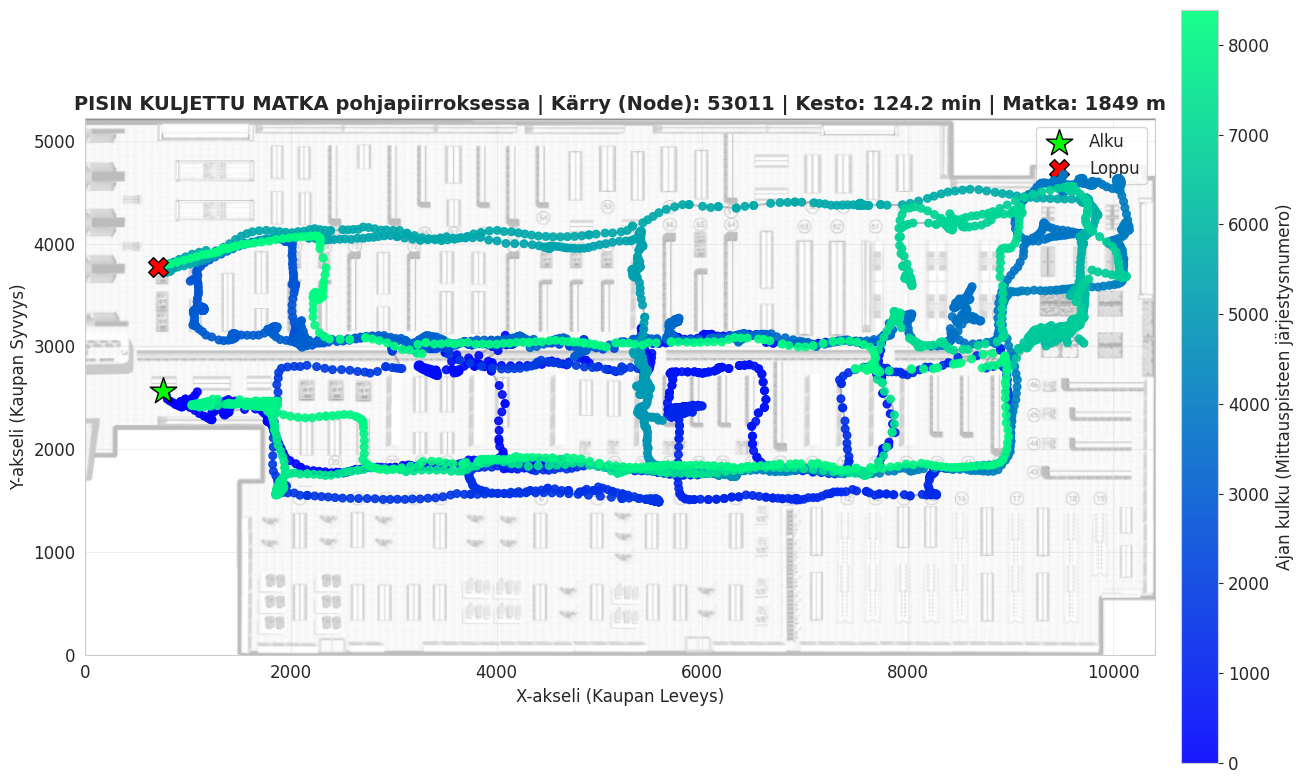

In [26]:
print("\n" + "="*60)
print(" 🕵️ REITTIEN JA POHJAPIIRROKSEN YHDISTÄMINEN (ÄÄRITAPAUKSET) ")
print("="*60)

if len(df_cleaned) > 0:
    unique_sessions = df_cleaned['full_session_id'].unique()
    
    session_distances = df_cleaned.groupby('full_session_id')['dist_m'].sum()
    session_durations = df_cleaned.groupby('full_session_id')['dt'].sum() / 60.0
    
    # Tunnistetaan ääritapaukset
    longest_dist_session = session_distances.idxmax()
    longest_time_session = session_durations.idxmax()
    
    def plot_specific_session(session_id, title_prefix):
        # Suodatetaan ja lajitellaan session data
        user_data = df_cleaned[df_cleaned['full_session_id'] == session_id].sort_values('timestamp')
        
        # Lasketaan tilastot reitille
        total_time = (user_data['timestamp'].max() - user_data['timestamp'].min()).total_seconds() / 60.0
        total_dist = user_data['dist_m'].sum()
        
        print(f"\n🔍 {title_prefix}: Sessio {session_id}")
        print(f"    - Aikaväli: {user_data['timestamp'].iloc[0].strftime('%Y-%m-%d %H:%M')} -> {user_data['timestamp'].iloc[-1].strftime('%H:%M')}")
        print(f"    - Datapisteitä: {len(user_data):,} kpl")
        print(f"    - Aikaa kului: {total_time:.1f} minuuttia")
        print(f"    - Kuljettu matka: {total_dist:.2f} metriä")
        
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # --- Lisää pohjapiirros taustalle ---
        img_path = Path('image/kauppa2.png')
        if img_path.exists():
            try:
                store_img = plt.imread(img_path)
                img_extent = [0, CLEANING_CONFIG['MAX_X'], 0, CLEANING_CONFIG['MAX_Y']]
                ax.imshow(store_img, extent=img_extent, origin='upper', aspect='auto', alpha=0.5, zorder=0)
            except Exception as e:
                pass # Ohita kuva jos virhe, piirrä vain data
        
        # Piirretään reitti harmaalla viivalla
        ax.plot(user_data['x'], user_data['y'], linewidth=1.5, color='gray', alpha=0.5, zorder=5)
        
        # Piirretään pisteet aikavärillä
        sc = ax.scatter(user_data['x'], user_data['y'], c=range(len(user_data)), cmap='winter', s=30, alpha=0.9, zorder=10)
        
        # Alku ja Loppu -merkinnät
        ax.scatter(user_data['x'].iloc[0], user_data['y'].iloc[0], color='lime', marker='*', s=400, edgecolor='black', zorder=15, label='Alku')
        ax.scatter(user_data['x'].iloc[-1], user_data['y'].iloc[-1], color='red', marker='X', s=200, edgecolor='black', zorder=15, label='Loppu')
        
        ax.set_xlabel('X-akseli (Kaupan Leveys)')
        ax.set_ylabel('Y-akseli (Kaupan Syvyys)')
        ax.set_title(f'{title_prefix} pohjapiirroksessa | Kärry (Node): {session_id.split("_")[0]} | Kesto: {total_time:.1f} min | Matka: {total_dist:.0f} m', fontsize=14, fontweight='bold')
        ax.set_aspect('equal') 
        ax.set_xlim(0, CLEANING_CONFIG['MAX_X'])
        ax.set_ylim(0, CLEANING_CONFIG['MAX_Y'])
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # Lisätään väripalkki ajan kululle
        plt.colorbar(sc, ax=ax, label='Ajan kulku (Mittauspisteen järjestysnumero)', pad=0.02)
        plt.tight_layout()
        plt.show()

    # Piirretään kaksi extreme-tapausta
    plot_specific_session(longest_dist_session, "PISIN KULJETTU MATKA")
    if longest_dist_session != longest_time_session:
        plot_specific_session(longest_time_session, "KAUIMMIN KESTÄNYT REISSU")
else:
    print("Ei dataa analysoitavaksi.")

## 🛤️ 9. Yksittäisen Satunnaisen Kauppareissun Seuranta (ja Nopeusprofiili)


 🛤️ REITTIKARTTA JA NOPEUSPROFIILI SATUNNAISELLE ASIAKKAALLE 

👤 Näytetään satunnainen ostoskierros: Sessio 51992_2953
    - Aikaleima alussa: 2019-12-07 16:27
    - Datapisteitä: 1404
    - Aikaa kului: 22.9 minuuttia
    - Kuljettu matka: 412.61 metriä
    - Keskinopeus: 0.30 m/s


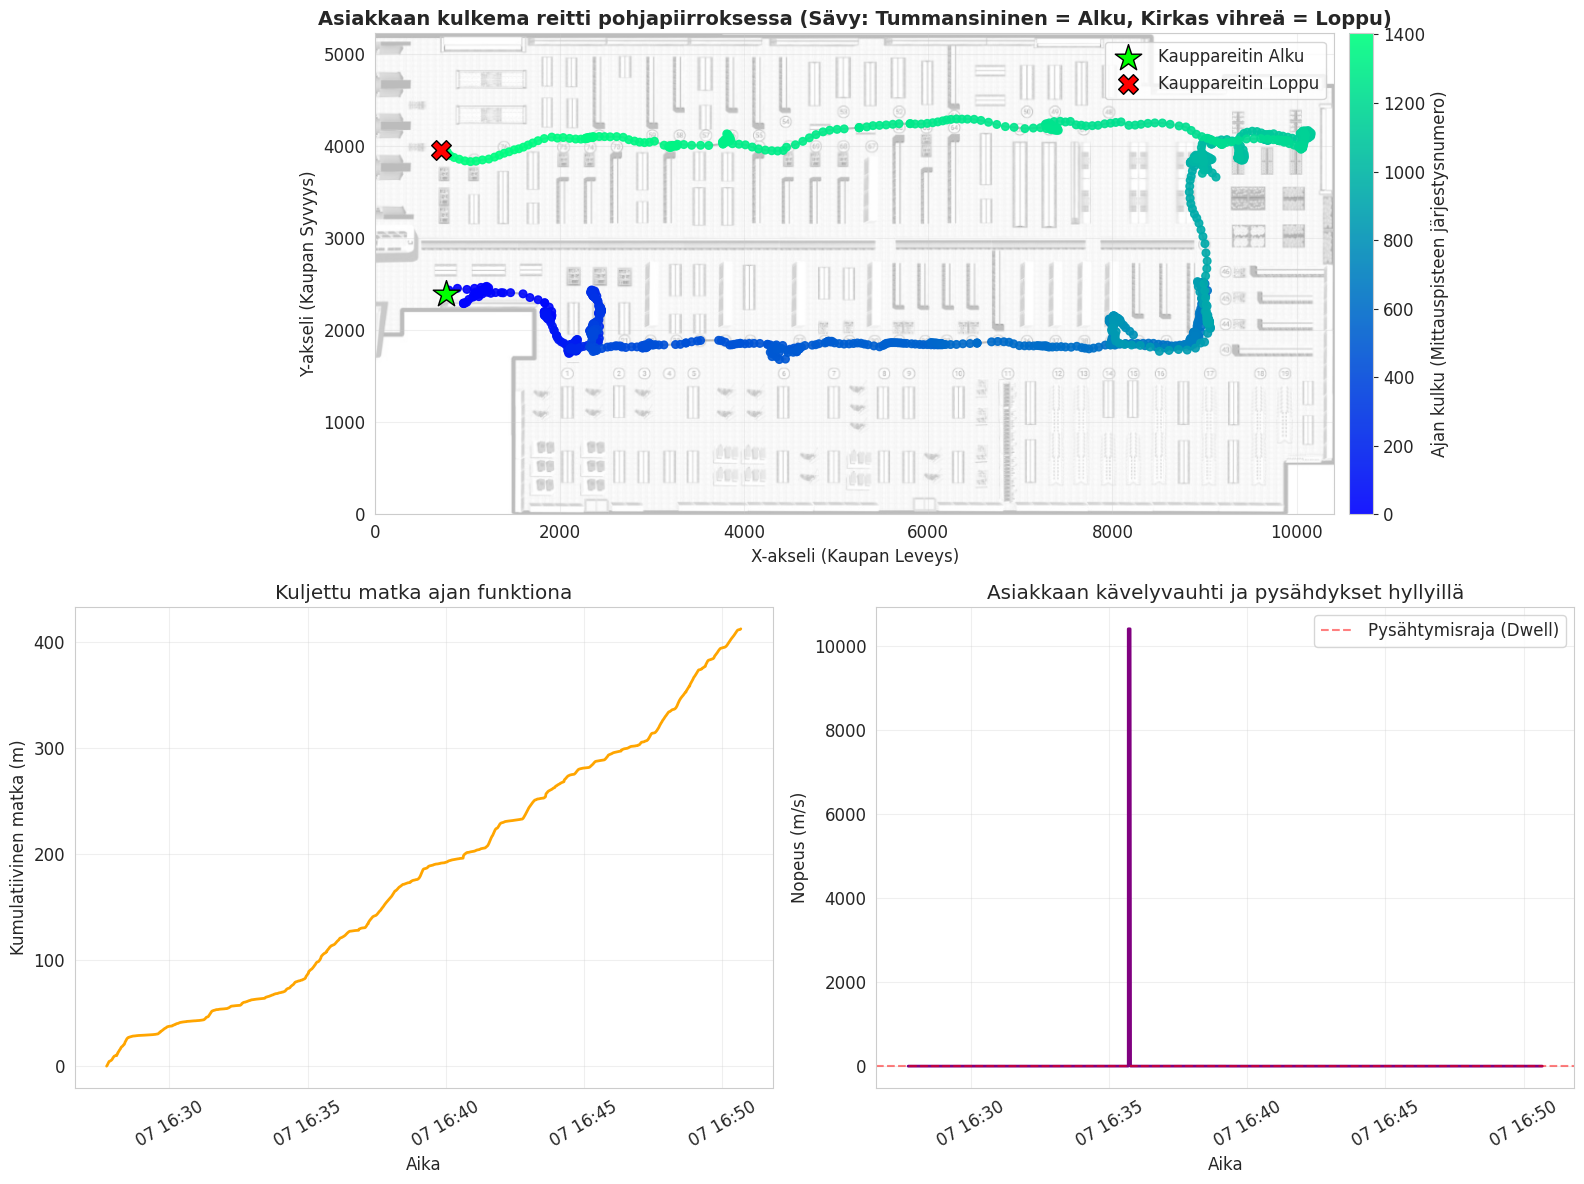

✅ Reitin visualisointi pohjapiirroksella valmis! Voit ajaa tämän solun uudestaan nähdäksesi eri asiakkaan reitin.


In [27]:
print("\n" + "="*60)
print(" 🛤️ REITTIKARTTA JA NOPEUSPROFIILI SATUNNAISELLE ASIAKKAALLE ")
print("="*60)

valid_sessions = df_cleaned['full_session_id'].unique()

if len(valid_sessions) > 0:
    # Valitaan satunnainen yksittäinen reissu
    random_session_id = np.random.choice(valid_sessions)
    user_data = df_cleaned[df_cleaned['full_session_id'] == random_session_id].sort_values('timestamp')
    
    # Lasketaan tilastot
    total_time = (user_data['timestamp'].max() - user_data['timestamp'].min()).total_seconds() / 60.0
    total_dist = user_data['dist_m'].sum()
    
    print(f"\n👤 Näytetään satunnainen ostoskierros: Sessio {random_session_id}")
    print(f"    - Aikaleima alussa: {user_data['timestamp'].iloc[0].strftime('%Y-%m-%d %H:%M')}")
    print(f"    - Datapisteitä: {len(user_data)}")
    print(f"    - Aikaa kului: {total_time:.1f} minuuttia")
    print(f"    - Kuljettu matka: {total_dist:.2f} metriä")
    print(f"    - Keskinopeus: {total_dist / (total_time * 60):.2f} m/s")
    
    # Määritetään kuvan koordinaatit
    img_path = Path('image/kauppa2.png')
    
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(2, 2)
    
    # --- 1. Reittikartta (Iso ruutu ylhäällä) ---
    ax1 = fig.add_subplot(gs[0, :])
    
    # --- Lisää pohjapiirros taustalle ---
    if img_path.exists():
        try:
            store_img = plt.imread(img_path)
            img_extent = [0, CLEANING_CONFIG['MAX_X'], 0, CLEANING_CONFIG['MAX_Y']]
            ax1.imshow(store_img, extent=img_extent, origin='upper', aspect='auto', alpha=0.5, zorder=0)
        except Exception as e:
            pass # Ohita kuva jos virhe, piirrä vain data
            
    # Piirretään reitti harmaalla viivalla
    ax1.plot(user_data['x'], user_data['y'], linewidth=1.5, color='gray', alpha=0.5, zorder=5)
    
    # Piirretään pisteet aikavärillä
    sc = ax1.scatter(user_data['x'], user_data['y'], c=range(len(user_data)), cmap='winter', s=30, alpha=0.9, zorder=10)
    
    # Alku ja Loppu -merkinnät
    ax1.scatter(user_data['x'].iloc[0], user_data['y'].iloc[0], color='lime', marker='*', s=400, edgecolor='black', zorder=15, label='Kauppareitin Alku')
    ax1.scatter(user_data['x'].iloc[-1], user_data['y'].iloc[-1], color='red', marker='X', s=200, edgecolor='black', zorder=15, label='Kauppareitin Loppu')
    
    ax1.set_xlabel('X-akseli (Kaupan Leveys)')
    ax1.set_ylabel('Y-akseli (Kaupan Syvyys)')
    ax1.set_title(f'Asiakkaan kulkema reitti pohjapiirroksessa (Sävy: Tummansininen = Alku, Kirkas vihreä = Loppu)', fontsize=14, fontweight='bold')
    ax1.set_aspect('equal') 
    ax1.set_xlim(0, CLEANING_CONFIG['MAX_X'])
    ax1.set_ylim(0, CLEANING_CONFIG['MAX_Y'])
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Väripalkki ajan kululle
    plt.colorbar(sc, ax=ax1, label='Ajan kulku (Mittauspisteen järjestysnumero)', pad=0.01)
    
    # --- 2. Etäisyyden kertyminen ---
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(user_data['timestamp'], user_data['dist_m'].cumsum(), linewidth=2, color='orange')
    ax2.set_xlabel('Aika')
    ax2.set_ylabel('Kumulatiivinen matka (m)')
    ax2.set_title('Kuljettu matka ajan funktiona')
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=30)
    
    # --- 3. Ostosreitin Nopeusprofiili ---
    ax3 = fig.add_subplot(gs[1, 1])
    # Tasataan nopeutta liukuvalla keskiarvolla
    smoothed_speed = user_data['speed_mps'].rolling(window=5, min_periods=1).mean()
    ax3.plot(user_data['timestamp'], smoothed_speed, linewidth=2, color='purple')
    ax3.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='Pysähtymisraja (Dwell)')
    ax3.set_xlabel('Aika')
    ax3.set_ylabel('Nopeus (m/s)')
    ax3.set_title('Asiakkaan kävelyvauhti ja pysähdykset hyllyillä')
    ax3.grid(True, alpha=0.3)
    ax3.tick_params(axis='x', rotation=30)
    ax3.legend()
    
    plt.tight_layout()
    plt.show()
    print("✅ Reitin visualisointi pohjapiirroksella valmis! Voit ajaa tämän solun uudestaan nähdäksesi eri asiakkaan reitin.")
else:
    print("Ei tarpeeksi selkeitä yksittäisiä reittejä visualisoitavaksi.")

## 📈 10. Aikasarja-analyysi


 📈 AIKASARJA-ANALYYSI 


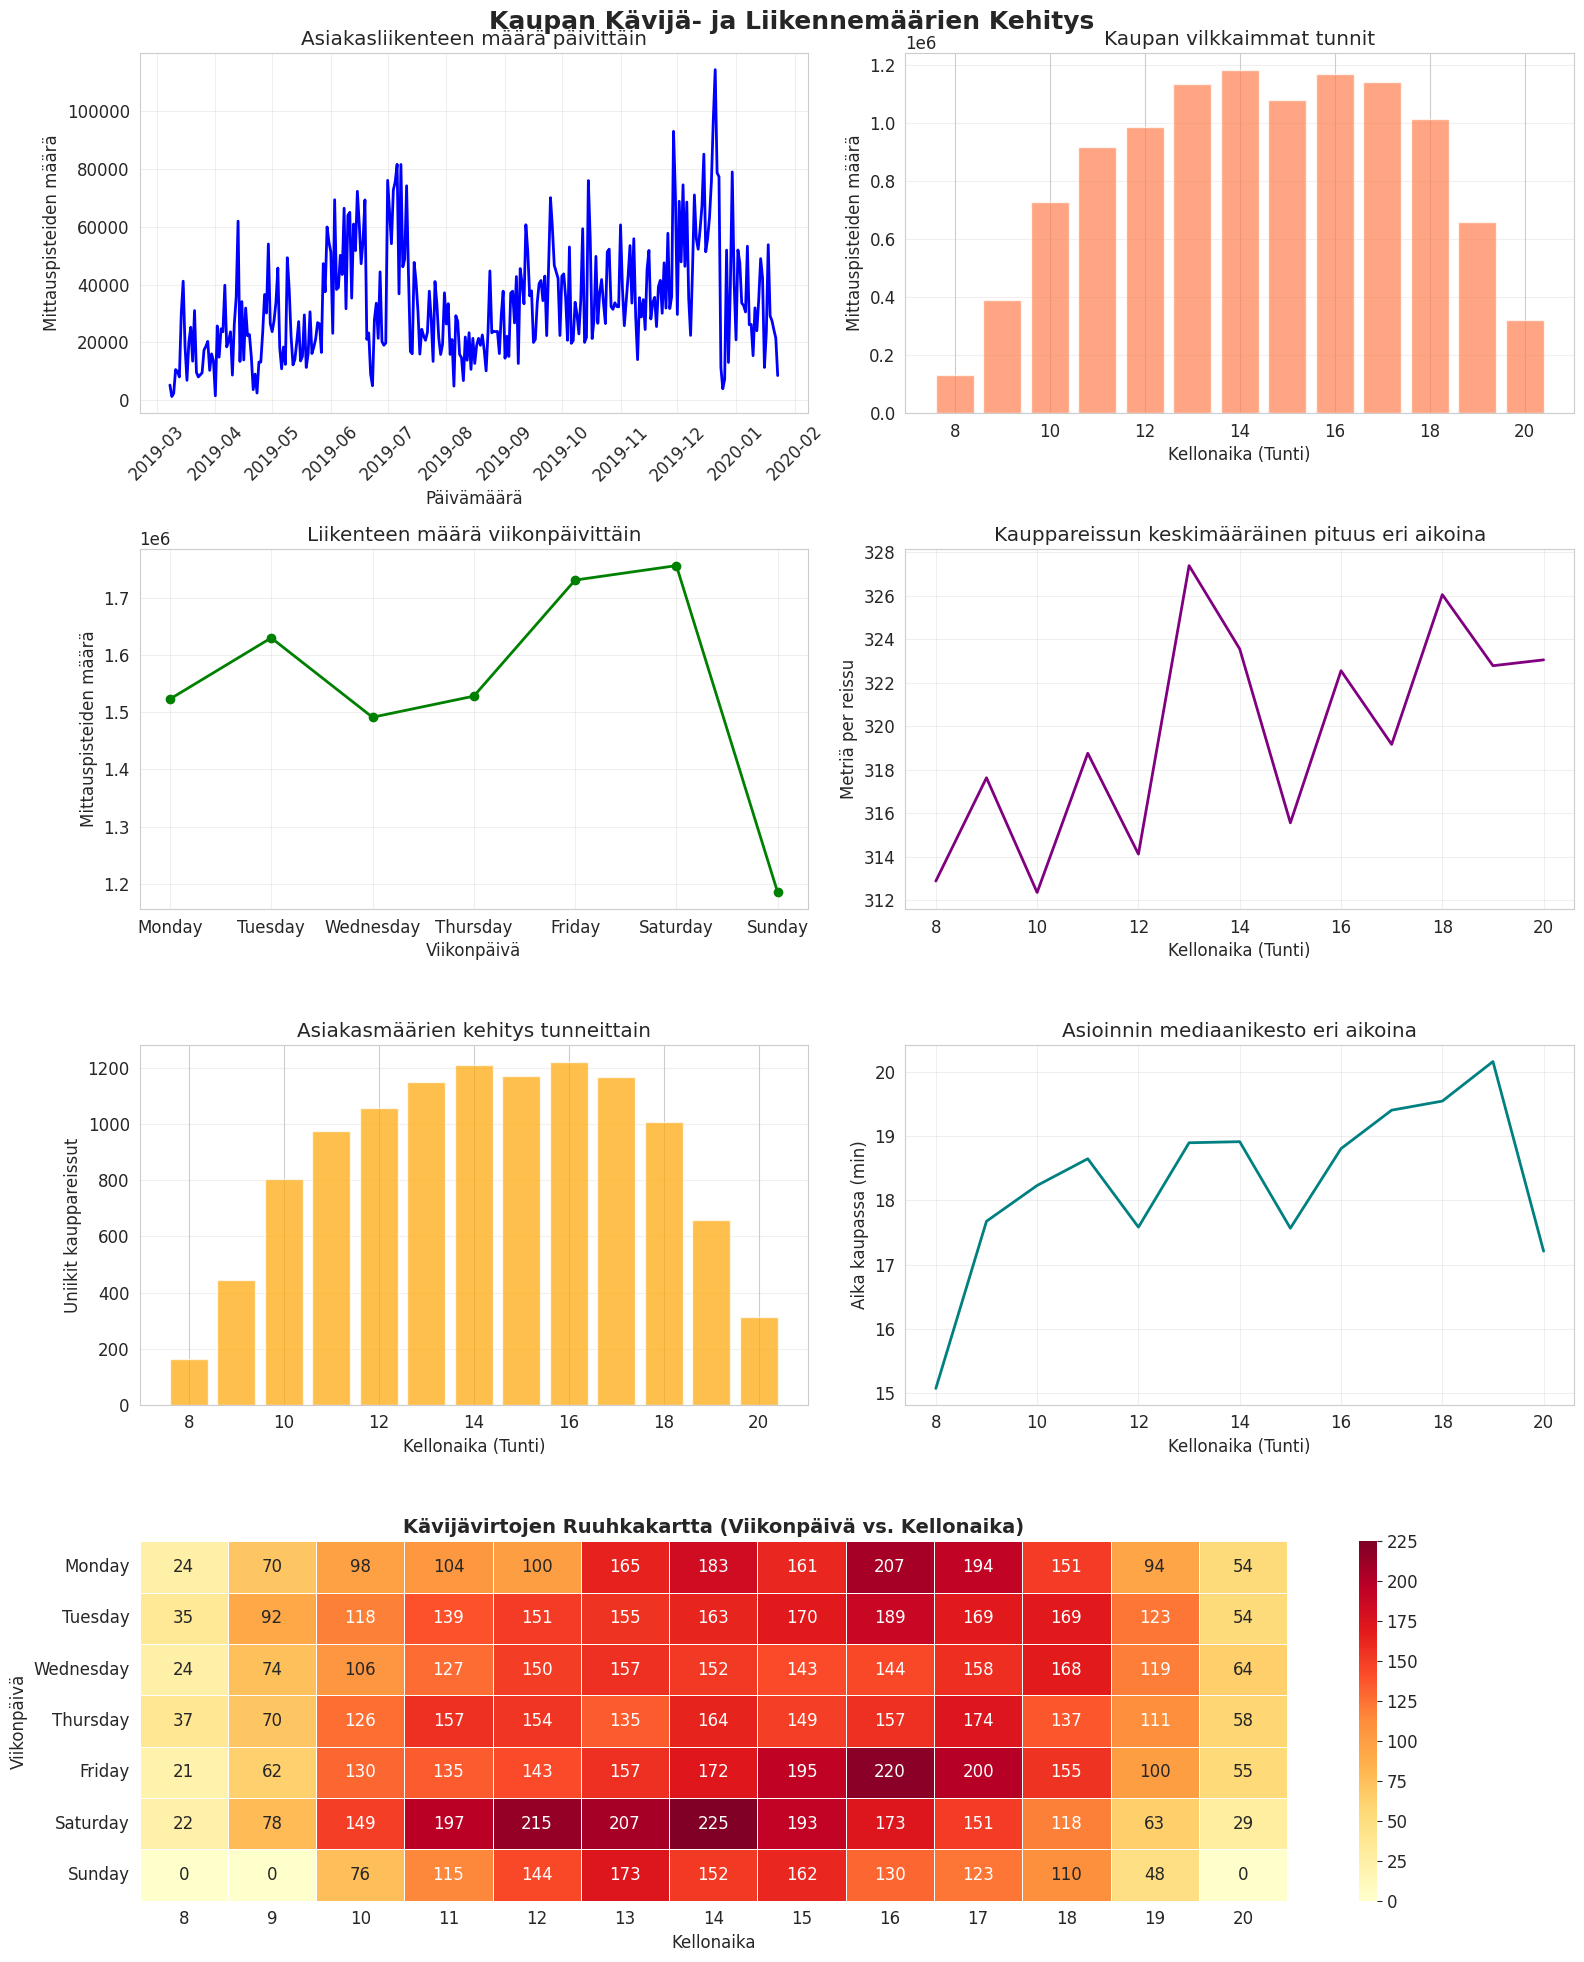

✅ Aikasarja-analyysi valmis!


In [28]:
print("\n" + "="*60)
print(" 📈 AIKASARJA-ANALYYSI ")
print("="*60)

# Rakennetaan viikonpäivä/tunti-lämpökartta vähittäiskaupan ammattilaisten tyyliin
fig = plt.figure(figsize=(16, 20))
gs = fig.add_gridspec(4, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, 0])
ax6 = fig.add_subplot(gs[2, 1])
ax7 = fig.add_subplot(gs[3, :]) # Iso lämpökartta alhaalla

fig.suptitle('Kaupan Kävijä- ja Liikennemäärien Kehitys', fontsize=18, fontweight='bold')

# 1. Havaintojen määrä päivittäin
daily_counts = df_cleaned.groupby('date').size()
ax1.plot(daily_counts.index, daily_counts.values, linewidth=2, color='blue')
ax1.set_xlabel('Päivämäärä')
ax1.set_ylabel('Mittauspisteiden määrä')
ax1.set_title('Asiakasliikenteen määrä päivittäin')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Havaintojen määrä tunnissa
hourly_counts = df_cleaned.groupby('hour').size()
ax2.bar(hourly_counts.index, hourly_counts.values, color='coral', alpha=0.7)
ax2.set_xlabel('Kellonaika (Tunti)')
ax2.set_ylabel('Mittauspisteiden määrä')
ax2.set_title('Kaupan vilkkaimmat tunnit')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Havaintojen määrä viikonpäivittäin
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df_cleaned.groupby('weekday').size().reindex(weekday_order)
ax3.plot(weekday_counts.index, weekday_counts.values, marker='o', linewidth=2, color='green')
ax3.set_xlabel('Viikonpäivä')
ax3.set_ylabel('Mittauspisteiden määrä')
ax3.set_title('Liikenteen määrä viikonpäivittäin')
ax3.grid(True, alpha=0.3)

# 4. Sessioiden keskimääräinen pituus tunnissa
avg_dist_hour = df_cleaned.groupby(['hour', 'full_session_id'])['dist_m'].sum().groupby('hour').mean()
ax4.plot(avg_dist_hour.index, avg_dist_hour.values, linewidth=2, color='purple')
ax4.set_xlabel('Kellonaika (Tunti)')
ax4.set_ylabel('Metriä per reissu')
ax4.set_title('Kauppareissun keskimääräinen pituus eri aikoina')
ax4.grid(True, alpha=0.3)

# 5. Uniikkien kauppareissujen (Sessioiden) määrä tunnissa
sessions_per_hour = df_cleaned.groupby('hour')['full_session_id'].nunique()
ax5.bar(sessions_per_hour.index, sessions_per_hour.values, color='orange', alpha=0.7)
ax5.set_xlabel('Kellonaika (Tunti)')
ax5.set_ylabel('Uniikit kauppareissut')
ax5.set_title('Asiakasmäärien kehitys tunneittain')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Kauppamatkojen mediaanikesto tunnissa
avg_duration_hour = df_cleaned.groupby('full_session_id')['dt'].sum() / 60.0
avg_duration_hour = pd.Series(avg_duration_hour).groupby(df_cleaned.groupby('full_session_id')['hour'].first()).median()
ax6.plot(avg_duration_hour.index, avg_duration_hour.values, linewidth=2, color='teal')
ax6.set_xlabel('Kellonaika (Tunti)')
ax6.set_ylabel('Aika kaupassa (min)')
ax6.set_title('Asioinnin mediaanikesto eri aikoina')
ax6.grid(True, alpha=0.3)

# 7. Viikonpäivä vs. Kellonaika -lämpökartta (Customer Traffic Heatmap)
traffic_pivot = df_cleaned.groupby(['weekday', 'hour'])['full_session_id'].nunique().unstack(fill_value=0)
traffic_pivot = traffic_pivot.reindex(weekday_order) # Varmistetaan järjestys Ma-Su
sns.heatmap(traffic_pivot, cmap='YlOrRd', ax=ax7, annot=True, fmt="d", linewidths=.5)
ax7.set_title('Kävijävirtojen Ruuhkakartta (Viikonpäivä vs. Kellonaika)', fontsize=14, fontweight='bold')
ax7.set_xlabel('Kellonaika')
ax7.set_ylabel('Viikonpäivä')

plt.tight_layout()
plt.show()

print("✅ Aikasarja-analyysi valmis!")

## 🌐 11. 3D-Tiheyskartta (Asiakasvirtojen määrä korkeutena)


 🌐 3D TIHEYSKARTTA (SURFACE PLOT) 


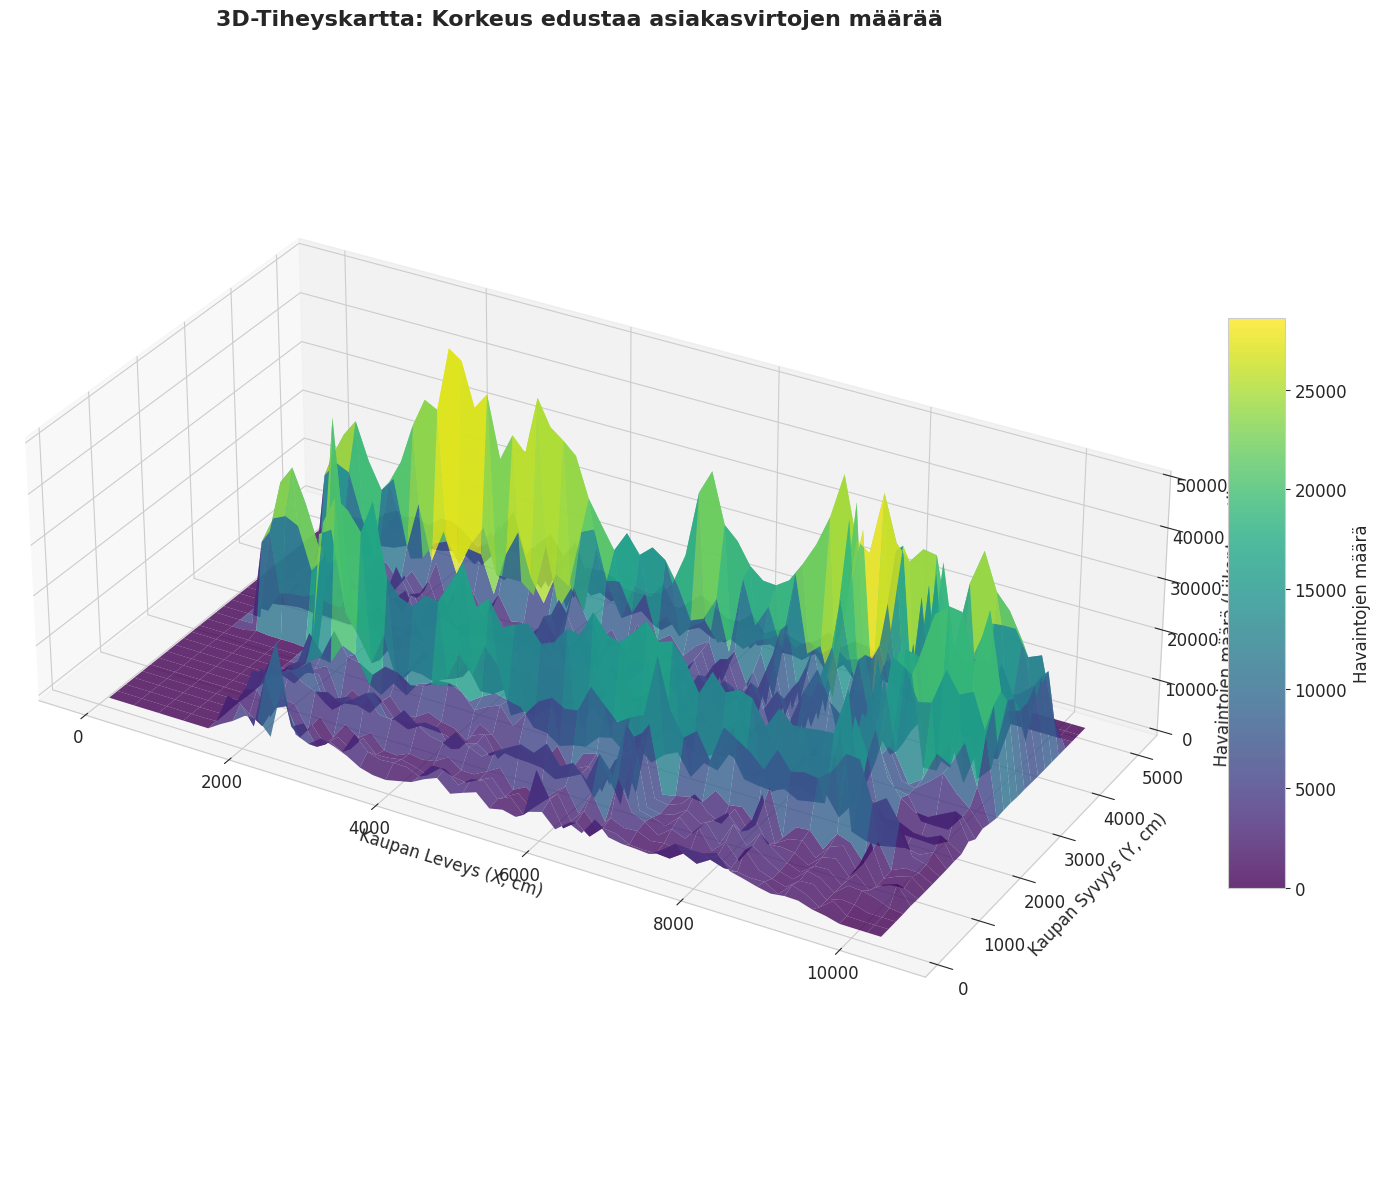

✅ 3D-tiheyskartta luotu!


In [29]:
print("\n" + "="*60)
print(" 🌐 3D TIHEYSKARTTA (SURFACE PLOT) ")
print("="*60)

hist, xedges, yedges = np.histogram2d(df_cleaned['x'], df_cleaned['y'], bins=[60, 30], range=[[0, CLEANING_CONFIG['MAX_X']], [0, CLEANING_CONFIG['MAX_Y']]])
xpos, ypos = np.meshgrid(xedges[:-1] + (xedges[1]-xedges[0])/2, yedges[:-1] + (yedges[1]-yedges[0])/2, indexing="ij")

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(xpos, ypos, hist, cmap='viridis', edgecolor='none', alpha=0.8)

ax.set_title('3D-Tiheyskartta: Korkeus edustaa asiakasvirtojen määrää', fontsize=16, fontweight='bold')
ax.set_xlabel('Kaupan Leveys (X, cm)')
ax.set_ylabel('Kaupan Syvyys (Y, cm)')
ax.set_zlabel('Havaintojen määrä (Liikenteen tiheys)')
ax.set_box_aspect((2, 1, 0.6))

fig.colorbar(surf, shrink=0.5, aspect=10, label='Havaintojen määrä')
plt.tight_layout()
plt.show()

print("✅ 3D-tiheyskartta luotu!")

## 📊 12. Signaalivahvuuden (Q-arvojen) Jakautuminen


 📊 Q-ARVOJEN (SIGNAALIVAHVUUDEN) JAKAUTUMINEN 


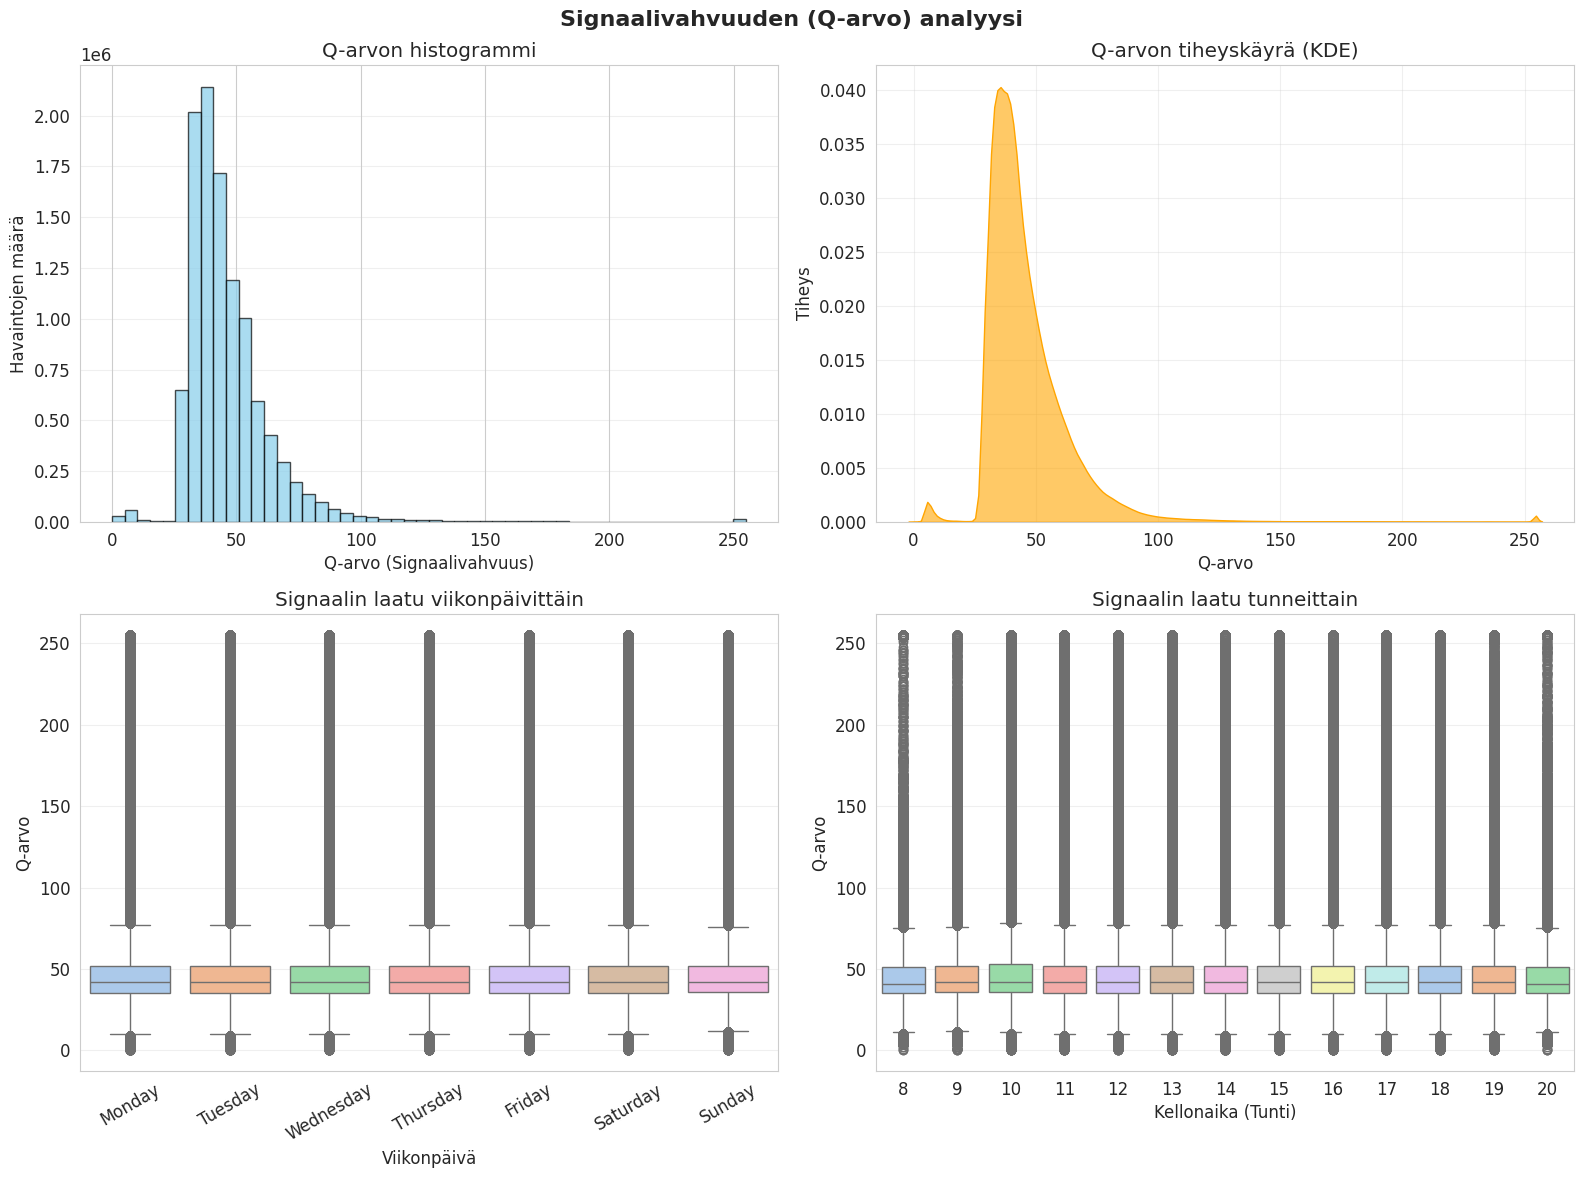

✅ Q-arvojen jakaumat visualisoitu!


In [30]:
if 'q' in df_cleaned.columns:
    print("\n" + "="*60)
    print(" 📊 Q-ARVOJEN (SIGNAALIVAHVUUDEN) JAKAUTUMINEN ")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Signaalivahvuuden (Q-arvo) analyysi', fontsize=16, fontweight='bold')

    axes[0, 0].hist(df_cleaned['q'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Q-arvo (Signaalivahvuus)')
    axes[0, 0].set_ylabel('Havaintojen määrä')
    axes[0, 0].set_title('Q-arvon histogrammi')
    axes[0, 0].grid(True, alpha=0.3, axis='y')

    sns.kdeplot(data=df_cleaned['q'], ax=axes[0, 1], fill=True, alpha=0.6, color='orange')
    axes[0, 1].set_xlabel('Q-arvo')
    axes[0, 1].set_ylabel('Tiheys')
    axes[0, 1].set_title('Q-arvon tiheyskäyrä (KDE)')
    axes[0, 1].grid(True, alpha=0.3)

    sns.boxplot(x='weekday', y='q', data=df_cleaned, order=weekday_order, ax=axes[1, 0], palette='pastel')
    axes[1, 0].set_xlabel('Viikonpäivä')
    axes[1, 0].set_ylabel('Q-arvo')
    axes[1, 0].set_title('Signaalin laatu viikonpäivittäin')
    axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=30)
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    valid_hours = sorted(df_cleaned['hour'].unique())
    sns.boxplot(x='hour', y='q', data=df_cleaned, ax=axes[1, 1], palette='pastel', order=valid_hours)
    axes[1, 1].set_xlabel('Kellonaika (Tunti)')
    axes[1, 1].set_ylabel('Q-arvo')
    axes[1, 1].set_title('Signaalin laatu tunneittain')
    axes[1, 1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print("✅ Q-arvojen jakaumat visualisoitu!")
else:
    print("⚠️ Saraketta 'q' ei löydy, ohitetaan signaalivahvuuden analyysi.")

## 📝 13. Datan Yhteenveto, Tallennus ja Verifiointi


 📝 DATAN LOPULLINEN YHTEENVETO 

DATAN LOPULLINEN YHTEENVETO KOKO TIETOVARASTOSTA:
-----------------------------------------------
- Lopullisia datapisteitä: 10,846,867
- Uniikkeja ostoskärryjä (Nodeja): 21
- Tunnistettuja aitoja kauppareissuja (Sessioita): 8,505

- Kattava aikaväli: 2019-03-08 - 2020-01-23
- Oikeat koordinaattirajat (cm): X: 0 - 10406, Y: 0 - 5220

- Kauppareissun mediaanikesto: 18.6 minuuttia
- Kauppareissun mediaanipituus: 399.95 metriä
- Signaalivahvuuden (Q) mediaani: 42.00

💾 Data tallennettu onnistuneesti: data/processed/processed_ALL_DATA.csv
   - Tiedostokoko: 1067.58 MB

✓ Verifiointi onnistui: Data luettavissa takaisin.
  - Rivejä: 10,846,867, Sarakkeita: 14
  - Muistinkäyttö: 3462.41 MB


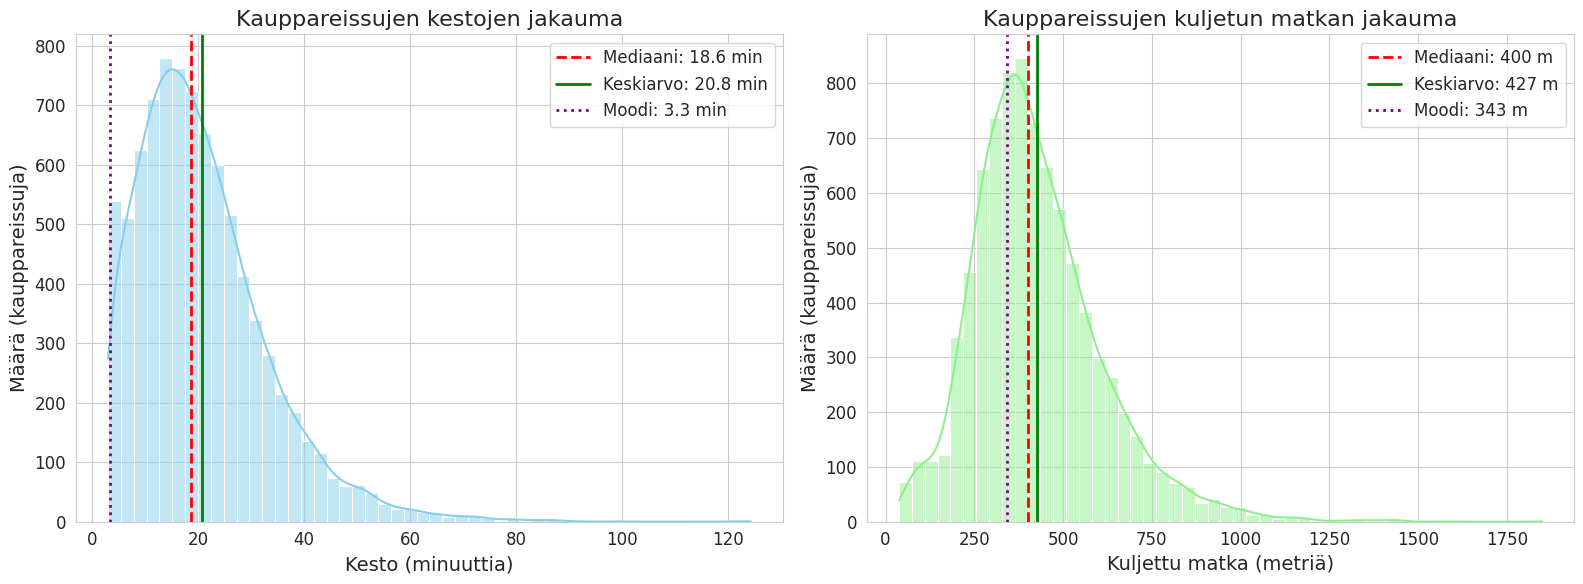


✅ Laajennettu analyysi ja Batch-prosessi on valmis!


In [32]:
print("\n" + "="*60)
print(" 📝 DATAN LOPULLINEN YHTEENVETO ")
print("="*60)

# Lasketaan lopulliset koosteet
session_durations = df_cleaned.groupby('full_session_id')['dt'].sum() / 60.0
session_distances = df_cleaned.groupby('full_session_id')['dist_m'].sum()

summary = f"""
DATAN LOPULLINEN YHTEENVETO KOKO TIETOVARASTOSTA:
-----------------------------------------------
- Lopullisia datapisteitä: {len(df_cleaned):,}
- Uniikkeja ostoskärryjä (Nodeja): {df_cleaned['node_id'].nunique()}
- Tunnistettuja aitoja kauppareissuja (Sessioita): {df_cleaned['full_session_id'].nunique():,}

- Kattava aikaväli: {df_cleaned['timestamp'].min().strftime('%Y-%m-%d')} - {df_cleaned['timestamp'].max().strftime('%Y-%m-%d')}
- Oikeat koordinaattirajat (cm): X: 0 - {CLEANING_CONFIG['MAX_X']}, Y: 0 - {CLEANING_CONFIG['MAX_Y']}

- Kauppareissun mediaanikesto: {session_durations.median():.1f} minuuttia
- Kauppareissun mediaanipituus: {session_distances.median():.2f} metriä
"""
if 'q' in df_cleaned.columns:
    summary += f"- Signaalivahvuuden (Q) mediaani: {df_cleaned['q'].median():.2f}\n"

print(summary)

# 2. Tallenna siivottu data dynaamisella nimellä
output_filename = "processed_ALL_DATA.csv"
output_path = processed_data_path / output_filename

# Varmistetaan, että hakemisto on olemassa
output_path.parent.mkdir(parents=True, exist_ok=True)

# Poistetaan turhat aputaulut ennen tallennusta
cols_to_drop = ['dt', 'dist_m', 'speed_mps']
df_final = df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns])

# Tallennetaan data
df_final.to_csv(output_path, index=False)
print(f"💾 Data tallennettu onnistuneesti: {output_path}")
print(f"   - Tiedostokoko: {output_path.stat().st_size / 1024 / 1024:.2f} MB")

# 3. Verifiointi: Luetaan data takaisin ja tarkistetaan, että kaikki on kunnossa
if output_path.exists():
    df_verify = pd.read_csv(output_path)
    print(f"\n✓ Verifiointi onnistui: Data luettavissa takaisin.")
    print(f"  - Rivejä: {len(df_verify):,}, Sarakkeita: {len(df_verify.columns)}")
    print(f"  - Muistinkäyttö: {df_verify.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")
else:
    print("\n✗ Virhe tallennuksessa: Tiedostoa ei löydy.")

# Kauppareissujen kestojen ja pituuksien jakaumat

# Luodaan kuva, jossa on kaksi vierekkäistä kuvaajaa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Kauppareissujen kestojen jakauma (minuuttia) ---
sns.histplot(session_durations, bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Kauppareissujen kestojen jakauma', fontsize=16)
axes[0].set_xlabel('Kesto (minuuttia)', fontsize=14)
axes[0].set_ylabel('Määrä (kauppareissuja)', fontsize=14)

# Mediaani, Keskiarvo ja Moodi
median_duration = session_durations.median()
mean_duration = session_durations.mean()
# Pyöristetään 1 desimaaliin, jotta jatkuvasta datasta saadaan looginen moodi
mode_duration = session_durations.round(1).mode()[0] 

axes[0].axvline(median_duration, color='red', linestyle='--', linewidth=2, label=f'Mediaani: {median_duration:.1f} min')
axes[0].axvline(mean_duration, color='green', linestyle='-', linewidth=2, label=f'Keskiarvo: {mean_duration:.1f} min')
axes[0].axvline(mode_duration, color='purple', linestyle=':', linewidth=2, label=f'Moodi: {mode_duration:.1f} min')
axes[0].legend()

# --- Kauppareissujen pituuksien jakauma (metriä) ---
sns.histplot(session_distances, bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Kauppareissujen kuljetun matkan jakauma', fontsize=16)
axes[1].set_xlabel('Kuljettu matka (metriä)', fontsize=14)
axes[1].set_ylabel('Määrä (kauppareissuja)', fontsize=14)

# Mediaani, Keskiarvo ja Moodi
median_distance = session_distances.median()
mean_distance = session_distances.mean()
# Pyöristetään tasametreihin, jotta jatkuvasta datasta saadaan looginen moodi
mode_distance = session_distances.round(0).mode()[0] 

axes[1].axvline(median_distance, color='red', linestyle='--', linewidth=2, label=f'Mediaani: {median_distance:.0f} m')
axes[1].axvline(mean_distance, color='green', linestyle='-', linewidth=2, label=f'Keskiarvo: {mean_distance:.0f} m')
axes[1].axvline(mode_distance, color='purple', linestyle=':', linewidth=2, label=f'Moodi: {mode_distance:.0f} m')
axes[1].legend()

# Viimeistellään asettelu, jotteivät tekstit mene päällekkäin
plt.tight_layout()
plt.show()

print("\n✅ Laajennettu analyysi ja Batch-prosessi on valmis!")